# Problem A — Binary Classification: Normal vs Affected
**Local execution version** (no Google Drive / Colab required)

**Set `BASE_DIR` in the Configuration cell to your MSK project folder.**

In [5]:
import os, json, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')
print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: []


## Configuration
Edit `BASE_DIR` to point to your local data folder.

In [6]:
# ── Paths ──────────────────────────────────────────────────
# Set BASE_DIR to the folder that contains:
#   PatientImages_MATCHED.xlsx
#   processed_images/
# (This is your local MSK project folder)
BASE_DIR    = r'.'                                 # <-- CHANGE IF NEEDED
EXCEL_PATH  = os.path.join(BASE_DIR, 'PatientImages_MATCHED.xlsx')
IMAGE_DIR   = os.path.join(BASE_DIR, 'processed_images')
RESULTS_DIR = os.path.join(BASE_DIR, 'results_A')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hyper-params ────────────────────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 32
LEARNING_RATE  = 1e-5
EPOCHS         = 50
UNFREEZE_LAYERS= 100
SEED           = 42
MODEL_OUT      = os.path.join(RESULTS_DIR, 'ResNet50_ProblemA_best.keras')

## Load & Label Data

In [7]:
df = pd.read_excel(EXCEL_PATH)
# Detect columns (handles multiline or unusual column names)
diag_col  = [c for c in df.columns if "diagn" in c.lower()][0]
image_col = [c for c in df.columns if c.strip().lower() == 'filename'] or             [c for c in df.columns if "image" in c.lower() or "file" in c.lower()]
image_col = image_col[0]
print("Diagnosis column :", diag_col)
print("Image column     :", image_col)
print("Unique diagnoses :", sorted(df[diag_col].dropna().unique()))

# Binary mapping: Normal=0, Affected=1
df['label'] = df[diag_col].apply(lambda x: 0 if str(x).strip().upper() == 'N' else 1)
df['path']  = df[image_col].apply(lambda f: os.path.join(IMAGE_DIR, str(f)))
df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)
print(f"Valid images: {len(df)}")
print(df['label'].value_counts().rename({0:'Normal', 1:'Affected'}))

Diagnosis column : Diagnosis
D - Dermatomyositis
P - Polymyositis
I - IBM
N - normal
Image column     : filename
Unique diagnoses : ['D', 'I', 'N', 'P']
Valid images: 586
label
Affected    340
Normal      246
Name: count, dtype: int64


## Train / Val / Test Split

In [8]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# Save splits
train_df[['path','label']].to_csv(os.path.join(RESULTS_DIR,'train_A.csv'), index=False)
val_df[['path','label']].to_csv(os.path.join(RESULTS_DIR,'val_A.csv'),   index=False)
test_df[['path','label']].to_csv(os.path.join(RESULTS_DIR,'test_A.csv'), index=False)

Train: 410  Val: 88  Test: 88


## Build tf.data Datasets

In [9]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

In [10]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.2),
    layers.RandomZoom(0.1),
], name="augmentation")

def make_dataset(dataframe, augment=False, shuffle=False):
    paths  = dataframe['path'].values
    labels = dataframe['label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1024)
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,  augment=False, shuffle=False)
test_ds  = make_dataset(test_df, augment=False, shuffle=False)
print("Datasets ready.")

Datasets ready.


## Class Weights

In [11]:
cw = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weight = dict(enumerate(cw))
print("Class weights:", class_weight)

Class weights: {0: np.float64(1.191860465116279), 1: np.float64(0.8613445378151261)}


## Build Model (ResNet50)

In [12]:
base = keras.applications.ResNet50(weights='imagenet', include_top=False,
                                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
# Freeze all, then unfreeze last UNFREEZE_LAYERS
for layer in base.layers:
    layer.trainable = False
for layer in base.layers[-UNFREEZE_LAYERS:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs, name='ResNet50_A')
model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 39s 0us/step


Model: "ResNet50_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 22,632,449 (86.34 MB)

 Non-trainable params: 1,480,064 (5.65 MB)

## Train

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
    keras.callbacks.ModelCheckpoint(MODEL_OUT, monitor='val_auc', save_best_only=True, mode='max'),
    keras.callbacks.CSVLogger(os.path.join(RESULTS_DIR, 'training_log_A.csv')),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)
print("Training complete.")

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.4829 - auc: 0.4744 - loss: 0.7335 - precision: 0.5691 - recall: 0.4496 - val_accuracy: 0.5227 - val_auc: 0.4724 - val_loss: 0.6929 - val_precision: 0.5600 - val_recall: 0.8235 - learning_rate: 1.0000e-05
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4902 - auc: 0.4901 - loss: 0.7042 - precision: 0.5668 - recall: 0.5168 - val_accuracy: 0.5795 - val_auc: 0.6020 - val_loss: 0.6826 - val_precision: 0.5795 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.4854 - auc: 0.5052 - loss: 0.7001 - precision: 0.5754 - recall: 0.4328 - val_accuracy: 0.4205 - val_auc: 0.5676 - val_loss: 0.6958 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 5s/step - accuracy: 0.4951 - auc: 0.4940 - loss: 0.7003 - precision: 0.5695 - recall: 0.5336 - val_accuracy: 0.5795 - val_auc: 0.7287 - val_loss: 

## Training Curves

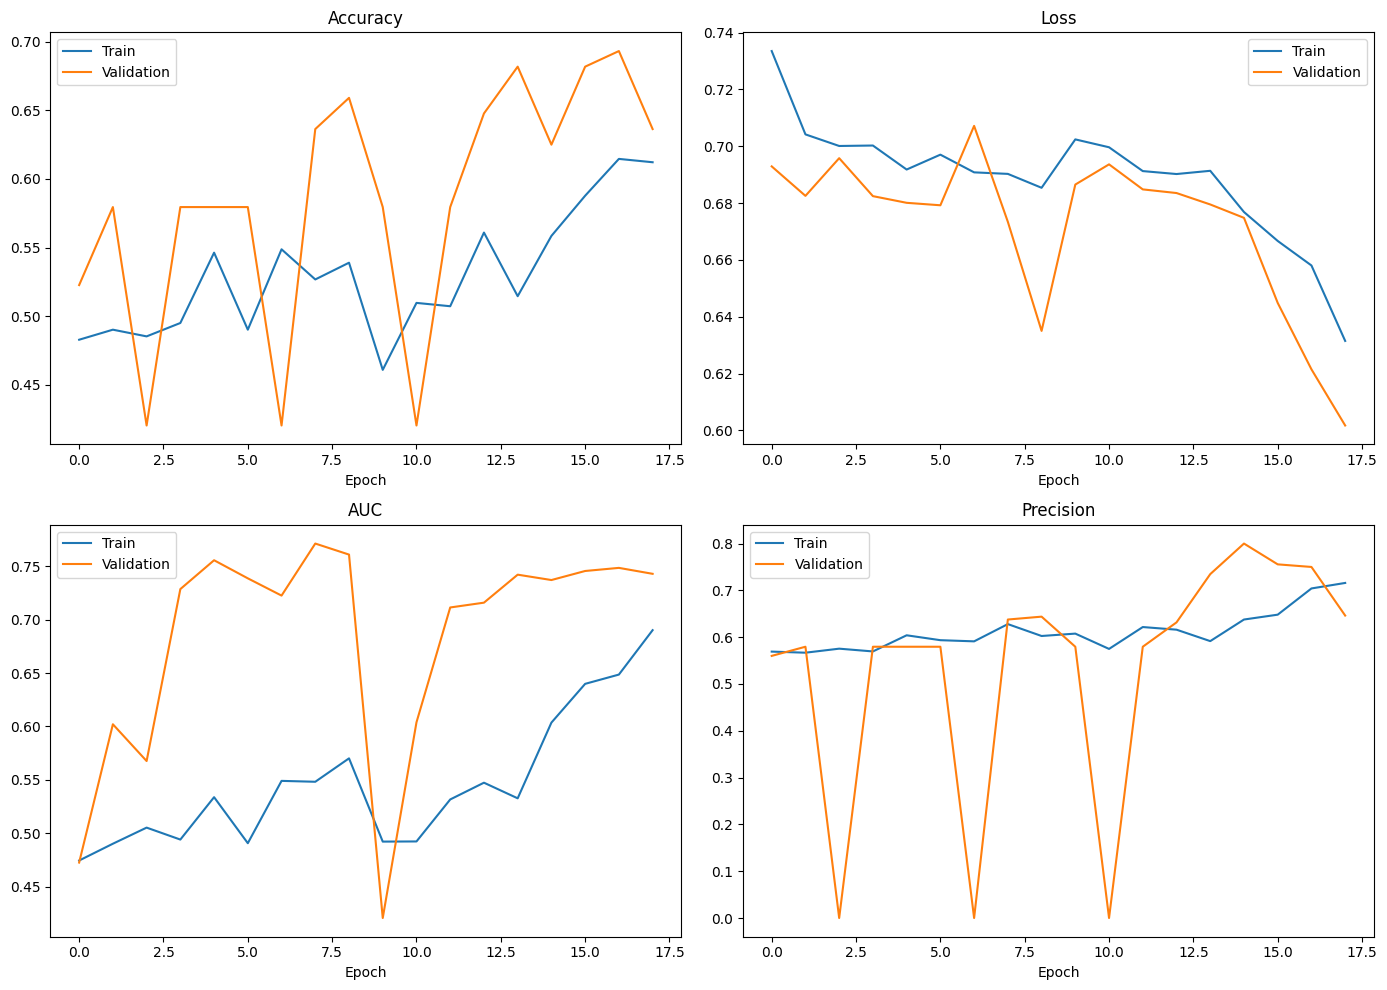

Training curves saved.


In [14]:
hist = history.history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, key, title in zip(axes.flatten(),
                          ['accuracy','loss','auc','precision'],
                          ['Accuracy','Loss','AUC','Precision']):
    ax.plot(hist[key],      label='Train')
    ax.plot(hist[f'val_{key}'], label='Validation')
    ax.set_title(title); ax.legend(); ax.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_curves_A.png'), dpi=150)
plt.show()
print("Training curves saved.")

## Evaluate on Test Set

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5909 - auc: 0.6582 - loss: 0.6795 - precision: 0.6000 - recall: 0.8824
  Test loss: 0.6795
  Test accuracy: 0.5909
  Test auc: 0.6582
  Test precision: 0.6000
  Test recall: 0.8824
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step


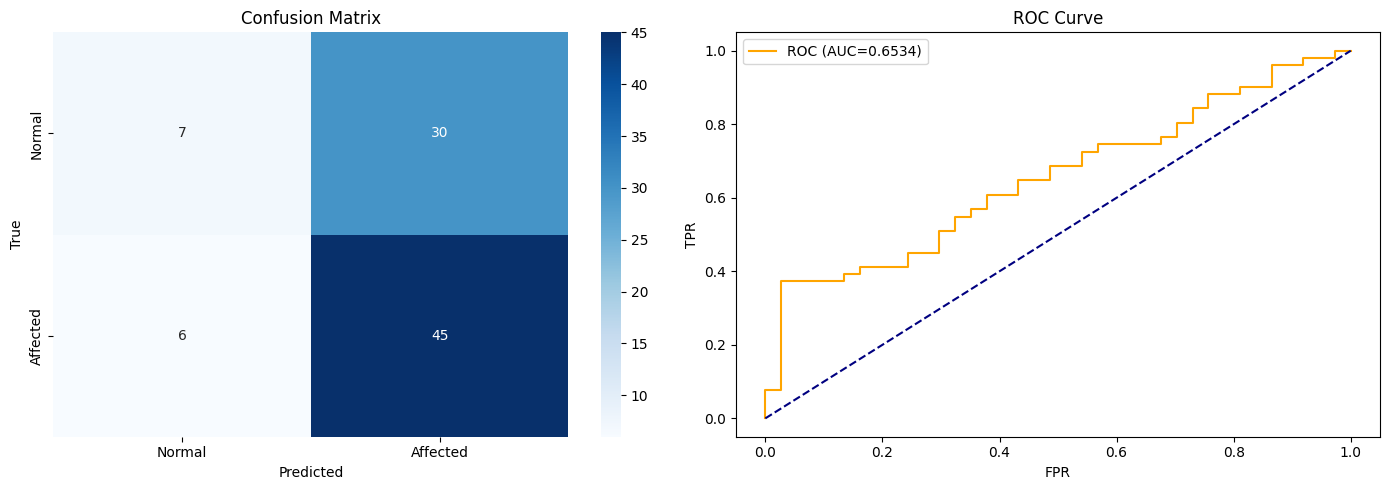

              precision    recall  f1-score   support

      Normal       0.54      0.19      0.28        37
    Affected       0.60      0.88      0.71        51

    accuracy                           0.59        88
   macro avg       0.57      0.54      0.50        88
weighted avg       0.57      0.59      0.53        88



In [15]:
test_metrics = model.evaluate(test_ds, verbose=1)
metric_names = ['loss','accuracy','auc','precision','recall']
for n, v in zip(metric_names, test_metrics):
    print(f"  Test {n}: {v:.4f}")

# Confusion matrix + ROC
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import roc_curve, auc as sk_auc
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = sk_auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax1, cmap='Blues',
            xticklabels=['Normal','Affected'], yticklabels=['Normal','Affected'])
ax1.set_title('Confusion Matrix'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')

ax2.plot(fpr, tpr, color='orange', label=f'ROC (AUC={roc_auc:.4f})')
ax2.plot([0,1],[0,1],'--', color='navy')
ax2.set_title('ROC Curve'); ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR'); ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_roc_A.png'), dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=['Normal','Affected']))

## Save Summary

In [16]:
summary = {
    'Model': 'ResNet50',
    'Problem': 'A  -  Normal vs Affected',
    'Test_Accuracy':  test_metrics[1],
    'Test_AUC':       test_metrics[2],
    'Test_Precision': test_metrics[3],
    'Test_Recall':    test_metrics[4],
    'Best_Val_Accuracy': max(history.history['val_accuracy']),
    'Best_Val_AUC':      max(history.history['val_auc']),
    'Epochs_Trained': len(history.history['accuracy']),
    'Learning_Rate':  LEARNING_RATE,
    'Unfreeze_Layers': UNFREEZE_LAYERS,
}
pd.DataFrame([summary]).to_csv(os.path.join(RESULTS_DIR, 'problem_A_summary.csv'), index=False)
print("Summary saved to", RESULTS_DIR)

Summary saved to .\results_A
